In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import odeint
import pandas as pd
import matplotlib.ticker as ticker

In [2]:
p = {
    'kk_1':  0.5,   
    'kk_2':  0.5,   
    'C50': 1.0,    
    'C_total': 2.0,
    'alpha_1': 0,
    'alpha_2': 0,
    'alpha_1_part': 0.5,
    'alpha_2_part': 0.5,
    'K':     1.0,    
    'beta':  0.2,    
    'mu':    0.1,    
    'rH':    0.1,   
    'rhor':  0.05,   
    'm':    3.2e-5  
}

In [3]:
y0 = [0.95,     
      0.05,   
      0.0,
      0.0,
      0.0]   
t = np.linspace(0, 2000, 2000)

In [4]:
def Hills_function (C, kk, C50):
    if C <= 0:
        return 0.0
    return (kk * C/ (C + C50))

def dose_distribution(C_total, r_2):
    C_dose1 = C_total * (1 - r_2)
    C_dose2  = C_total * r_2
    return C_dose1, C_dose2 
    
C_dose1, C_dose2 = dose_distribution(p['C_total'], 0.5)

e_1 = Hills_function(C_dose1,p['kk_1'],p['C50'])
e_2 = Hills_function(C_dose2,p['kk_2'],p['C50'])

b_ab = p['beta']*(1-e_1)*(1-e_2)
b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

In [5]:
def ODEs (y,t,p,b_ab, b_Ab, b_aB, b_AB):
    H, I_ab, I_Ab, I_aB, I_AB = y
    m = p['m']
    rH = p ['rH']
    K = p['K']
    mu = p['mu']

    dH = rH*(K - H - I_ab - I_Ab - I_aB - I_AB) - b_ab*I_ab*H - b_Ab*I_Ab*H - b_aB*I_aB*H - b_AB*I_AB*H
    dI_ab = (1-2*m)*b_ab*I_ab*H + m*b_Ab*I_Ab*H + m*b_aB*I_aB*H - mu*I_ab
    dI_Ab = m*b_ab*I_ab*H + (1-2*m)*b_Ab*I_Ab*H + m*b_AB*I_AB*H - mu*I_Ab
    dI_aB = m*b_ab*I_ab*H + (1-2*m)*b_aB*I_aB*H + m*b_AB*I_AB*H - mu*I_aB
    dI_AB = m*b_Ab*I_Ab*H + m*b_aB*I_aB*H + (1-2*m)*b_AB*I_AB*H - mu*I_AB

    return [dH, dI_ab, dI_Ab, dI_aB, dI_AB]

In [6]:
def calculate_90_threshold(sol, t):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    I_AB = sol[:,4]

    valid = np.isfinite(I_total) & np.isfinite(I_AB)

    I_total_safe = np.where(valid, I_total, 0.0)
    I_AB_safe = np.where(valid, I_AB, 0.0)

    proportion = np.zeros_like(I_total_safe)

    mask = I_total_safe > 1e-8
    proportion[mask] = I_AB_safe[mask] / I_total_safe[mask]

    indices = np.where(proportion >= 0.9)[0]

    if len(indices) > 0:
        return t[indices[0]]
    else:
        return np.nan

#### strain dynamics under fungicide dose variation

In [7]:
dosage_range = np.linspace(0,2,9)
dosage_results= []
full_dynamics = []

for dosage in dosage_range:
    p_c = p.copy()
    p_c['C_total'] = dosage
    C_dose1, C_dose2 = dose_distribution(p_c['C_total'], 0.5)

    e_1 = Hills_function(C_dose1,p_c['kk_1'],p_c['C50'])
    e_2 = Hills_function(C_dose2,p_c['kk_2'],p_c['C50'])

    b_ab = p_c['beta']*(1-e_1)*(1-e_2)
    b_Ab = p_c['beta']*(1-p_c['rhor'])*(1-e_2)
    b_aB = p_c['beta']*(1-e_1)*(1-p_c['rhor'])
    b_AB = p_c['beta']*(1-p_c['rhor'])*(1-p_c['rhor'])

    b_total = (b_ab, b_Ab, b_aB, b_AB)
    sol_dosage = odeint(ODEs, y0, t, args=(p_c,*b_total))

    t_90 = calculate_90_threshold(sol_dosage, t)

    dosage_results.append(t_90)
    full_dynamics.append(sol_dosage)

In [8]:
rows = []

for i, sol in enumerate(full_dynamics):

    rows.append([
        dosage_range[i],
        sol[-1,0],  
        sol[-1,1],  
        sol[-1,2],  
        sol[-1,3],  
        sol[-1,4],  
        dosage_results[i]
    ])

df_summary = pd.DataFrame(rows, columns=[
    "Dosage",
    "H",
    "$I_{ab}$",
    "$I_{Ab}$",
    "$I_{aB}$",
    "$I_{AB}$",
    "90%$I_{AB}$time"
])

df_summary

,Dosage,H,$I_{ab}$,$I_{Ab}$,$I_{aB}$,$I_{AB}$,90%$I_{AB}$time
0,0.00,0.500032,2.496643e-01,0.000160,0.000160,9.964591e-08,NaN
1,0.25,0.560474,2.144319e-01,0.002649,0.002649,3.304996e-05,NaN
2,0.50,0.555302,1.592843e-04,0.004434,0.004434,2.133392e-01,1818.909455
3,0.75,0.554053,2.777212e-08,0.000080,0.000080,2.228129e-01,1041.520760
4,1.00,0.554052,1.414535e-08,0.000058,0.000058,2.228578e-01,749.374687
5,1.25,0.554052,9.348587e-09,0.000048,0.000048,2.228787e-01,595.297649
6,1.50,0.554052,6.911205e-09,0.000041,0.000041,2.228915e-01,500.250125
7,1.75,0.554052,5.474893e-09,0.000037,0.000037,2.229000e-01,435.217609
8,2.00,0.554052,4.544718e-09,0.000034,0.000034,2.229062e-01,388.194097


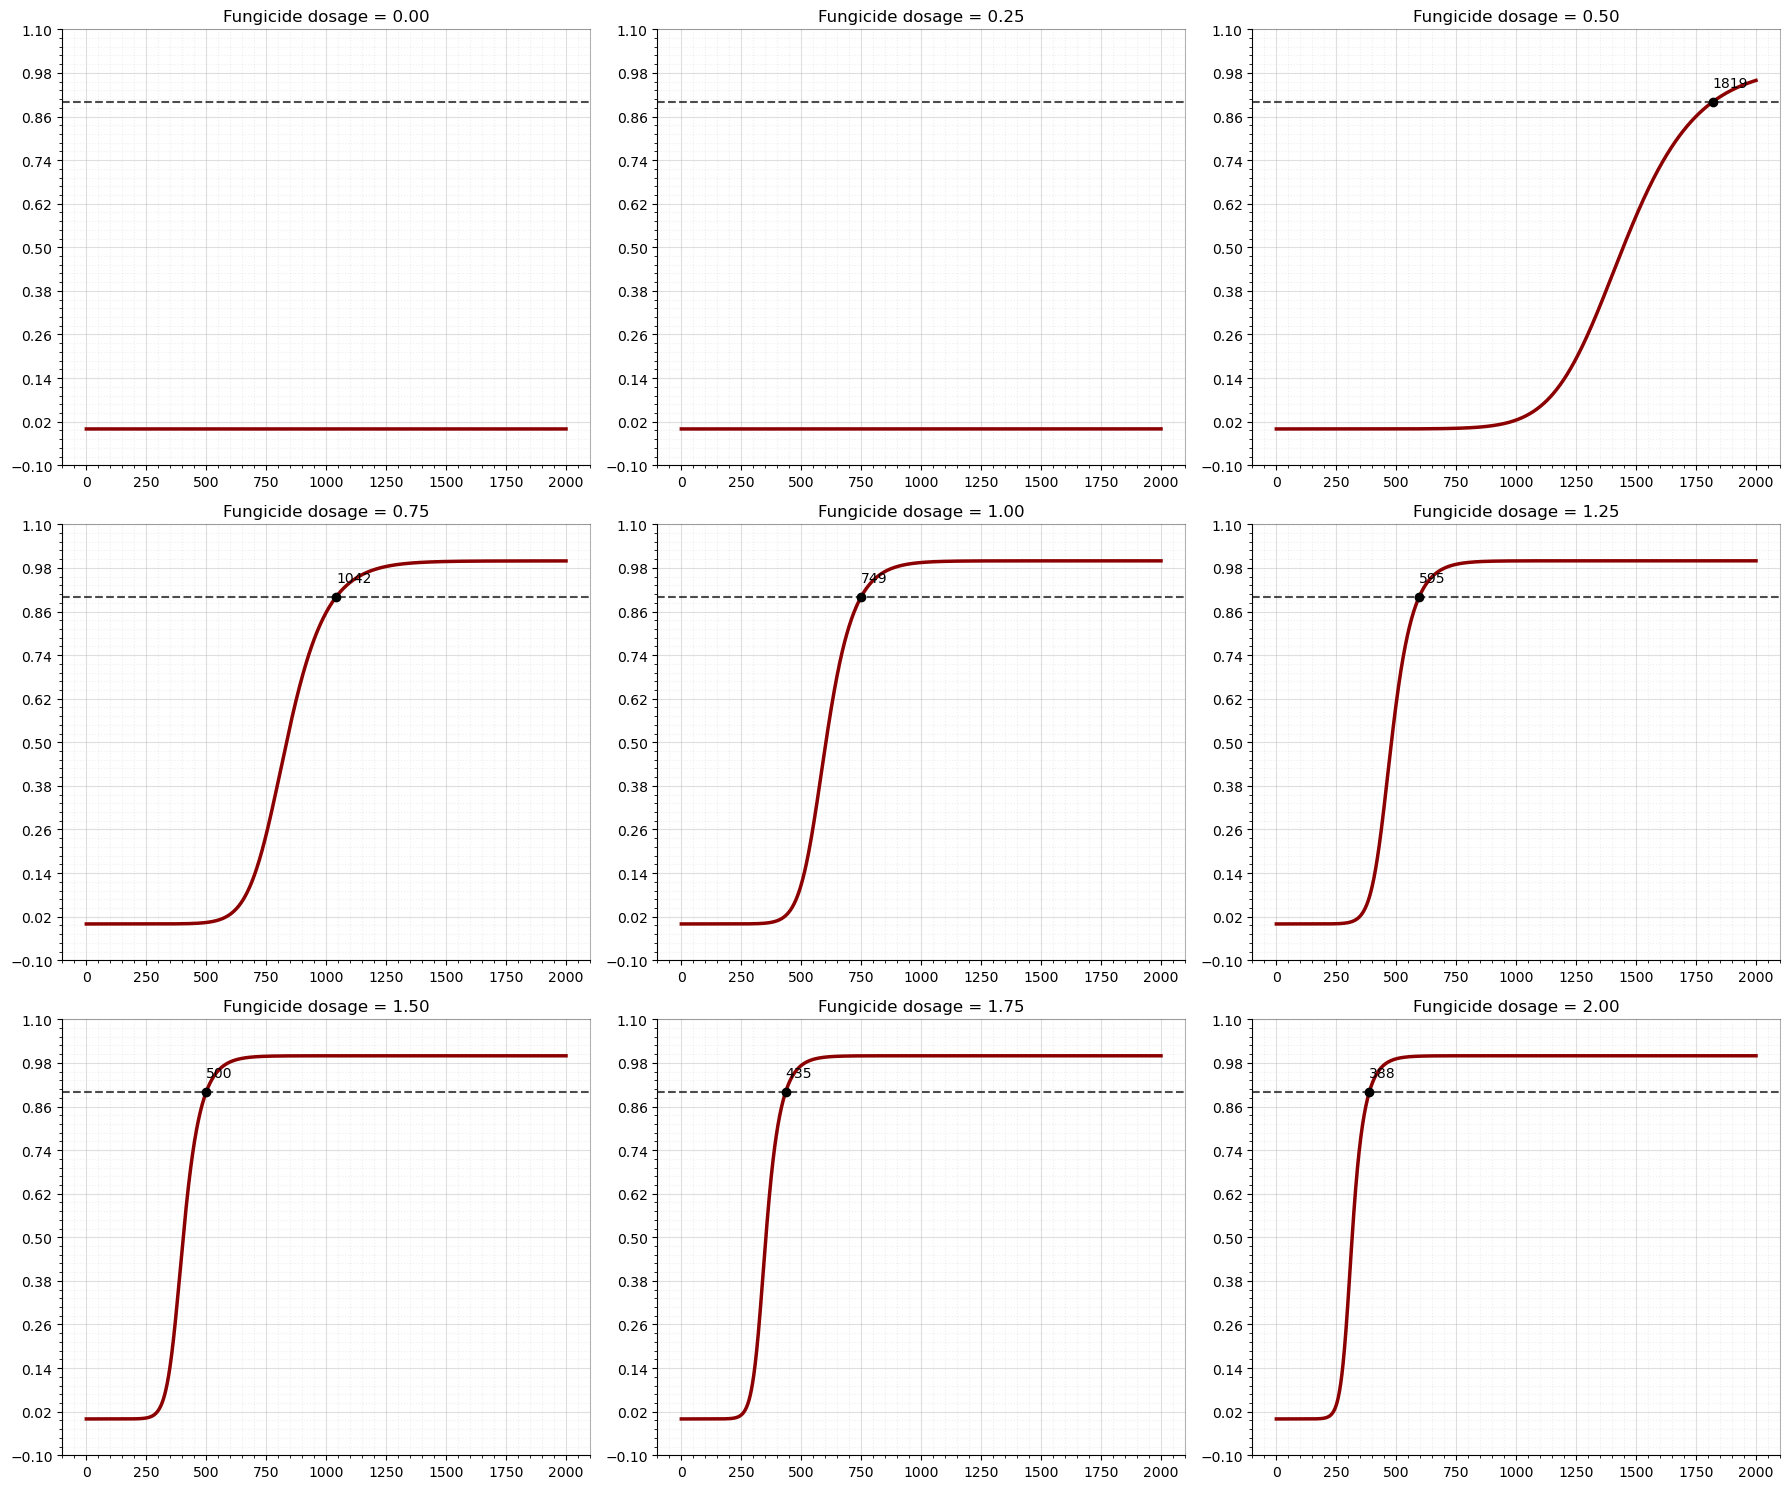

In [9]:
n = len(dosage_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

def calculate_I_AB_proportion(sol):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    return np.divide(sol[:,4], I_total, out=np.zeros_like(I_total), where=(I_total!=0))

for i, dose in enumerate (dosage_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]

    sol = full_dynamics[i]

    I_AB_prop = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_prop, color='darkred', linewidth=2.5)
    ax.axhline(0.9, color='black', linestyle='--', alpha=0.7)

    indices = np.where(I_AB_prop >= 0.9)[0]
    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_prop[indices[0]], 'ko')
        ax.text(hit_time, 0.94, f'{hit_time:.0f}', fontsize=10)

    ax.set_title(f"Fungicide dosage = {dose:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

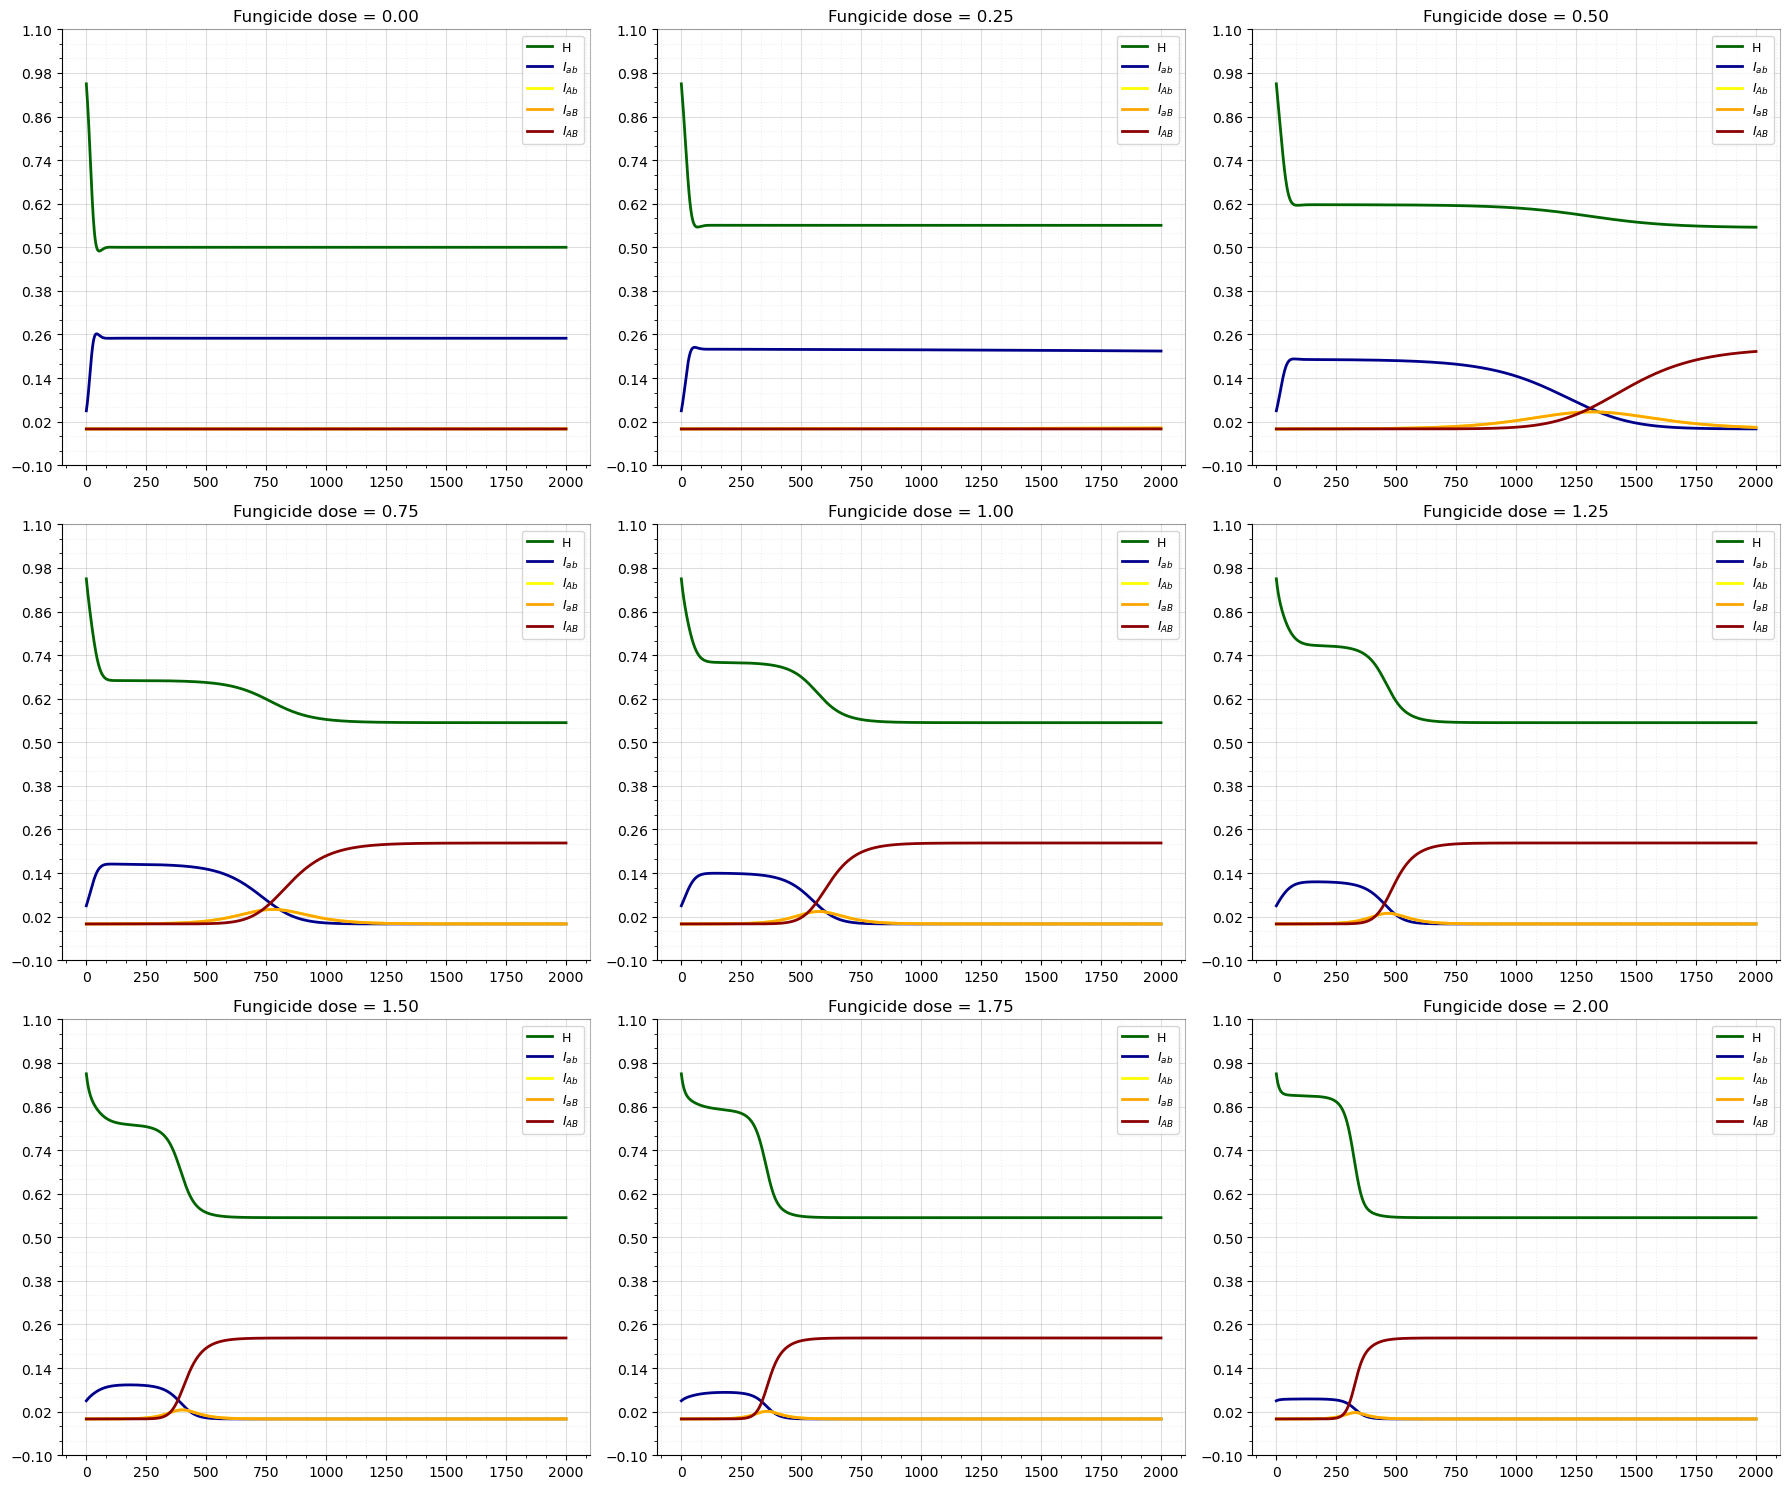

In [10]:
n = len(dosage_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, dose in enumerate (dosage_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]

    sol = full_dynamics[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], label=labels[j], linewidth=2)

    ax.set_title(f"Fungicide dose = {dose:.2f}", fontsize=12)
    ax.set_ylim(-0.05, 1.1)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))

    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

#### strain dynamics under fitness cost variation

In [89]:
fitness_range = np.linspace(0,0.3,12)
fitness_results= []
full_fitness_dynamics = []

C_dose1, C_dose2 = dose_distribution(p['C_total'], 0.5)

e_1 = Hills_function(C_dose1, p['kk_1'], p['C50'])
e_2 = Hills_function(C_dose2, p['kk_2'], p['C50'])

for cost in fitness_range:
    p_c = p.copy()
    p_c['rhor'] = cost

    b_ab = p_c['beta']*(1-e_1)*(1-e_2)
    b_Ab = p_c['beta']*(1-p_c['rhor'])*(1-e_2)
    b_aB = p_c['beta']*(1-e_1)*(1-p_c['rhor'])
    b_AB = p_c['beta']*(1-p_c['rhor'])*(1-p_c['rhor'])

    b_total = (b_ab, b_Ab, b_aB, b_AB)
    sol_cost = odeint(ODEs, y0, t, args=(p_c,*b_total))

    t_90 = calculate_90_threshold(sol_cost, t)

    fitness_results.append(t_90)
    full_fitness_dynamics.append(sol_cost)

In [90]:
rows = []

for i, sol in enumerate(full_fitness_dynamics):

    rows.append([
        fitness_range[i],
        sol[-1,0],  
        sol[-1,1],  
        sol[-1,2],  
        sol[-1,3],  
        sol[-1,4],  
        fitness_results[i]
    ])

df_summary = pd.DataFrame(rows, columns=[
    "fitness cost",
    "H",
    "$I_{ab}$",
    "$I_{Ab}$",
    "$I_{aB}$",
    "$I_{AB}$",
    "90%$I_{AB}$time"
])

df_summary

,fitness cost,H,$I_{ab}$,$I_{Ab}$,$I_{aB}$,$I_{AB}$,90%$I_{AB}$time
0,0.000000,0.500032,3.510183e-09,0.000032,0.000032,2.499200e-01,304.152076
1,0.027273,0.528464,4.008690e-09,0.000033,0.000033,2.357020e-01,345.172586
2,0.054545,0.559392,4.675452e-09,0.000034,0.000034,2.202357e-01,398.199100
3,0.081818,0.593117,5.585644e-09,0.000036,0.000036,2.033704e-01,466.233117
4,0.109091,0.629986,6.920736e-09,0.000037,0.000037,1.849321e-01,560.280140
5,0.136364,0.670403,9.058929e-09,0.000040,0.000040,1.647184e-01,696.348174
6,0.163636,0.714838,1.300099e-08,0.000044,0.000044,1.424925e-01,912.456228
7,0.190909,0.763891,1.009956e-07,0.000093,0.000093,1.178701e-01,1315.657829
8,0.218182,0.833447,3.723682e-03,0.012155,0.012155,5.537734e-02,NaN
9,0.245455,0.888765,5.425580e-02,0.000677,0.000677,8.528666e-06,NaN


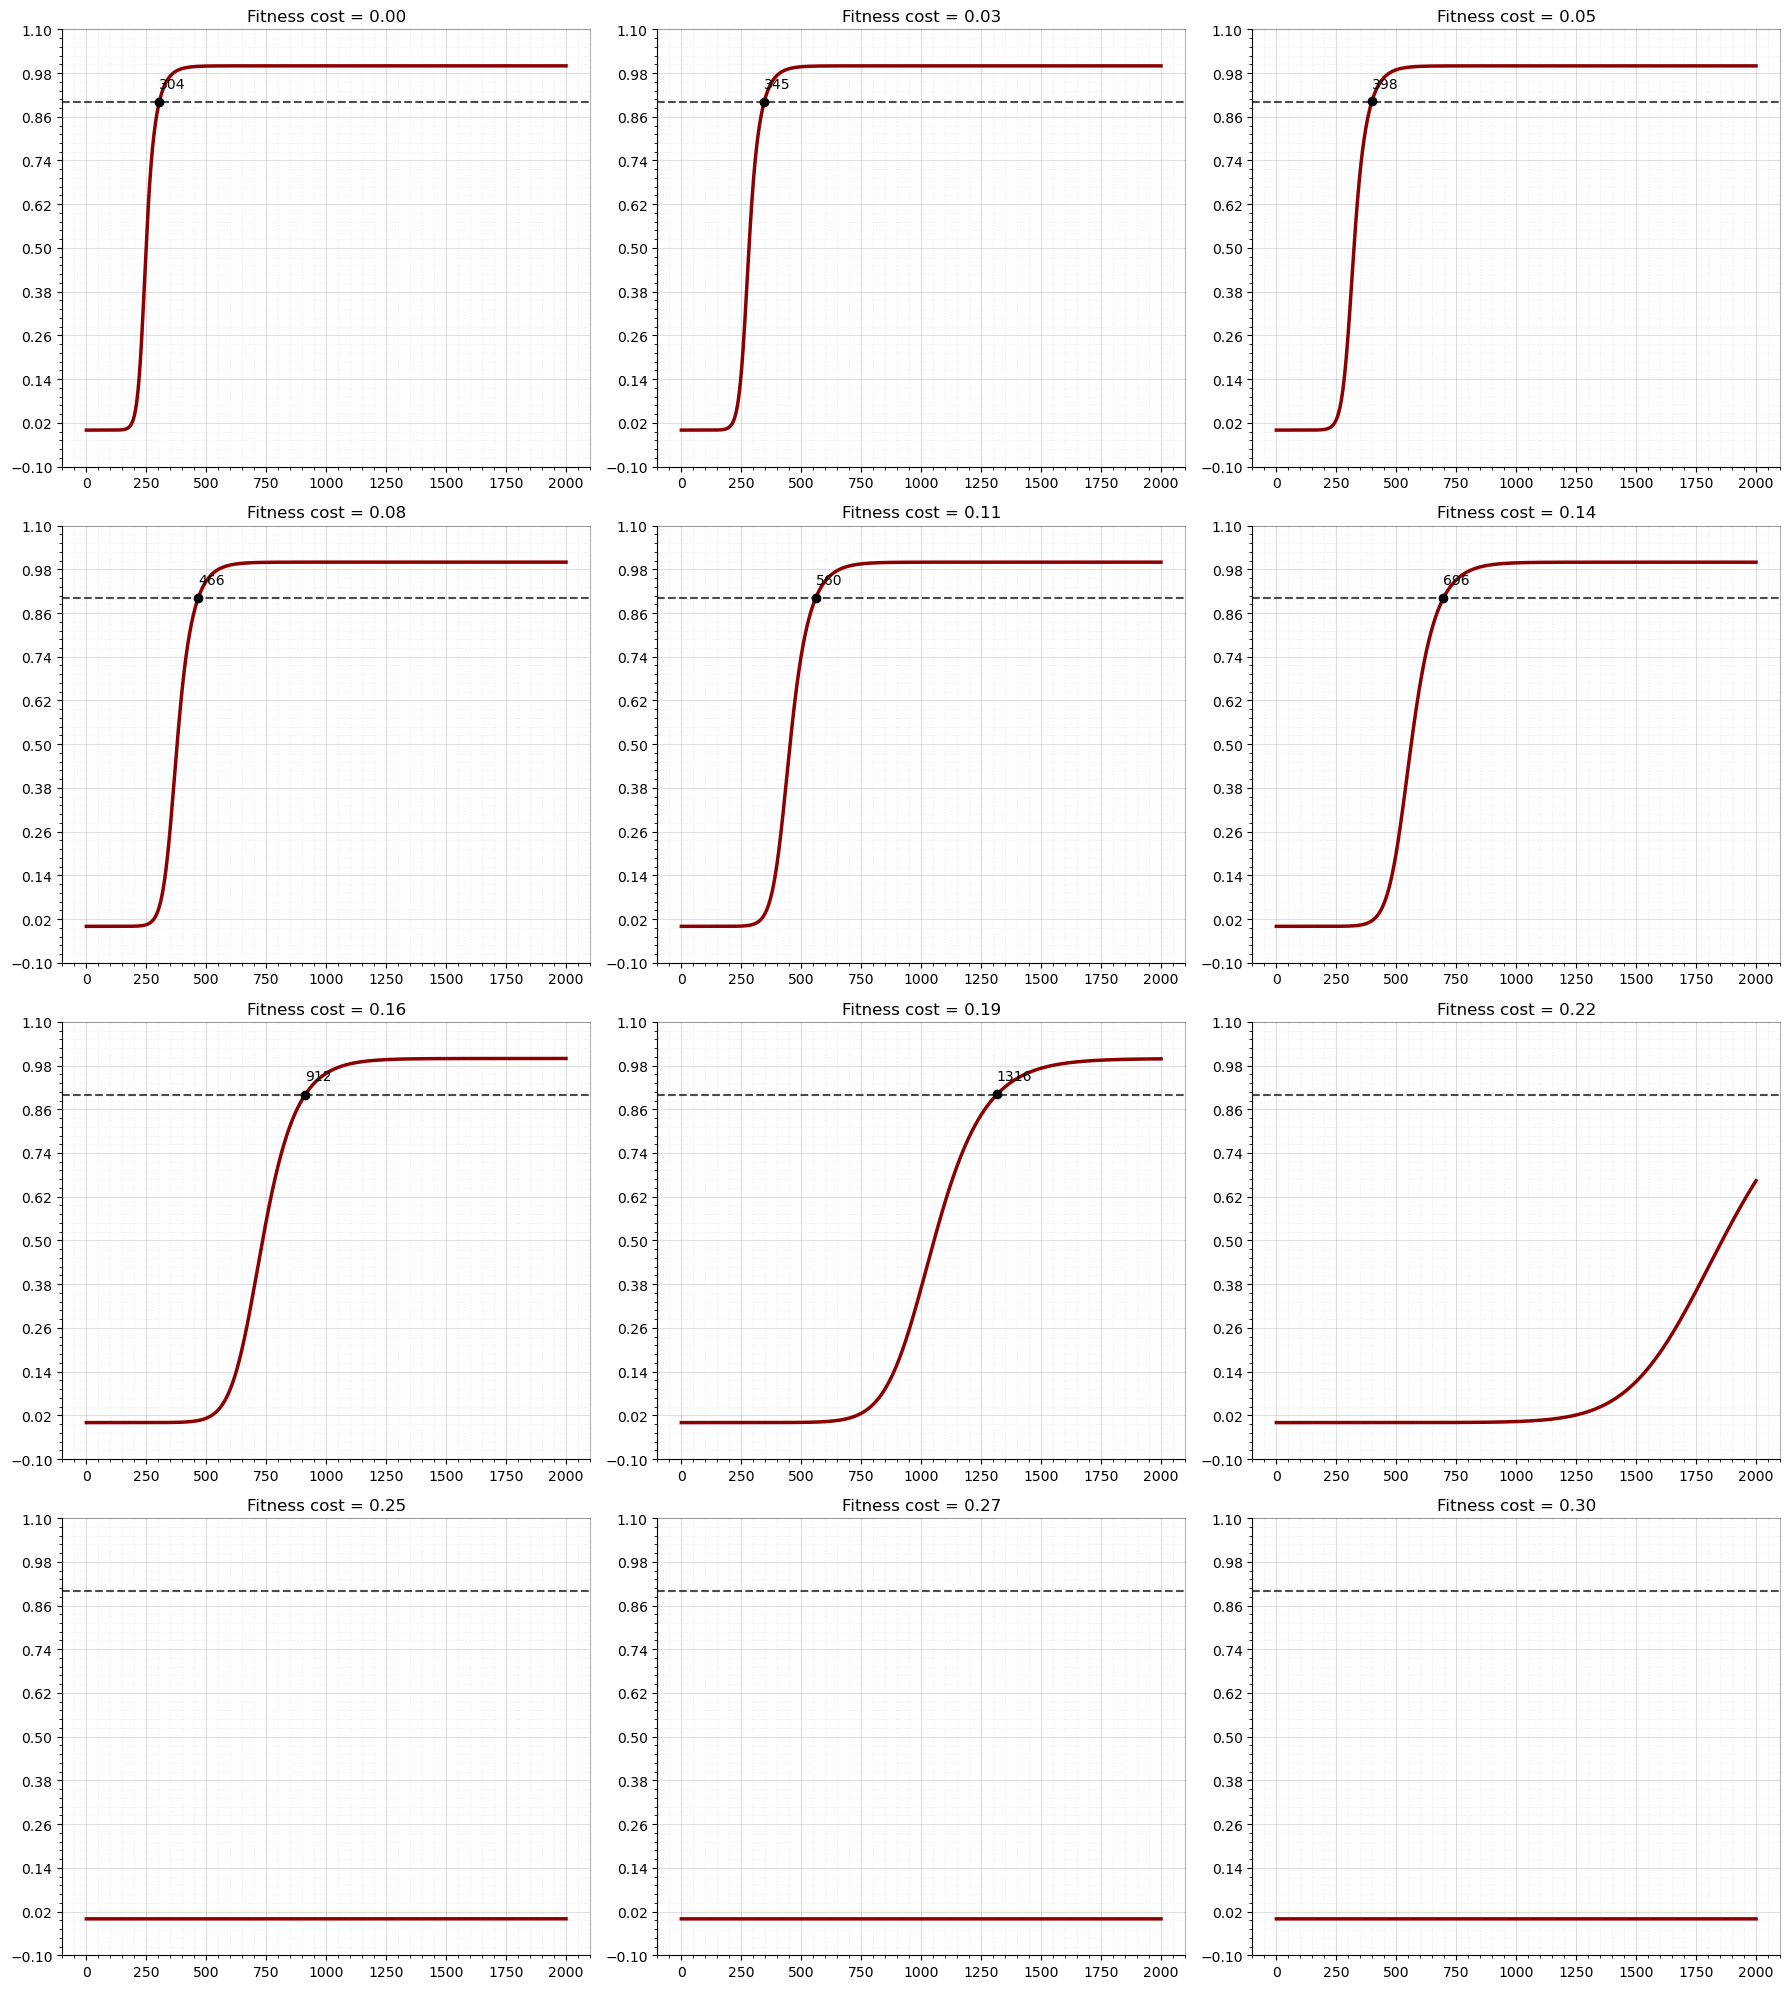

In [91]:
n = len(fitness_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

def calculate_I_AB_proportion(sol):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    return np.divide(sol[:,4], I_total, out=np.zeros_like(I_total), where=(I_total!=0))

for i, cost in enumerate (fitness_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]

    sol = full_fitness_dynamics[i]

    I_AB_prop = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_prop, color='darkred', linewidth=2.5)
    ax.axhline(0.9, color='black', linestyle='--', alpha=0.7)

    indices = np.where(I_AB_prop >= 0.9)[0]
    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_prop[indices[0]], 'ko')
        ax.text(hit_time, 0.94, f'{hit_time:.0f}', fontsize=10)

    ax.set_title(f"Fitness cost = {cost:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

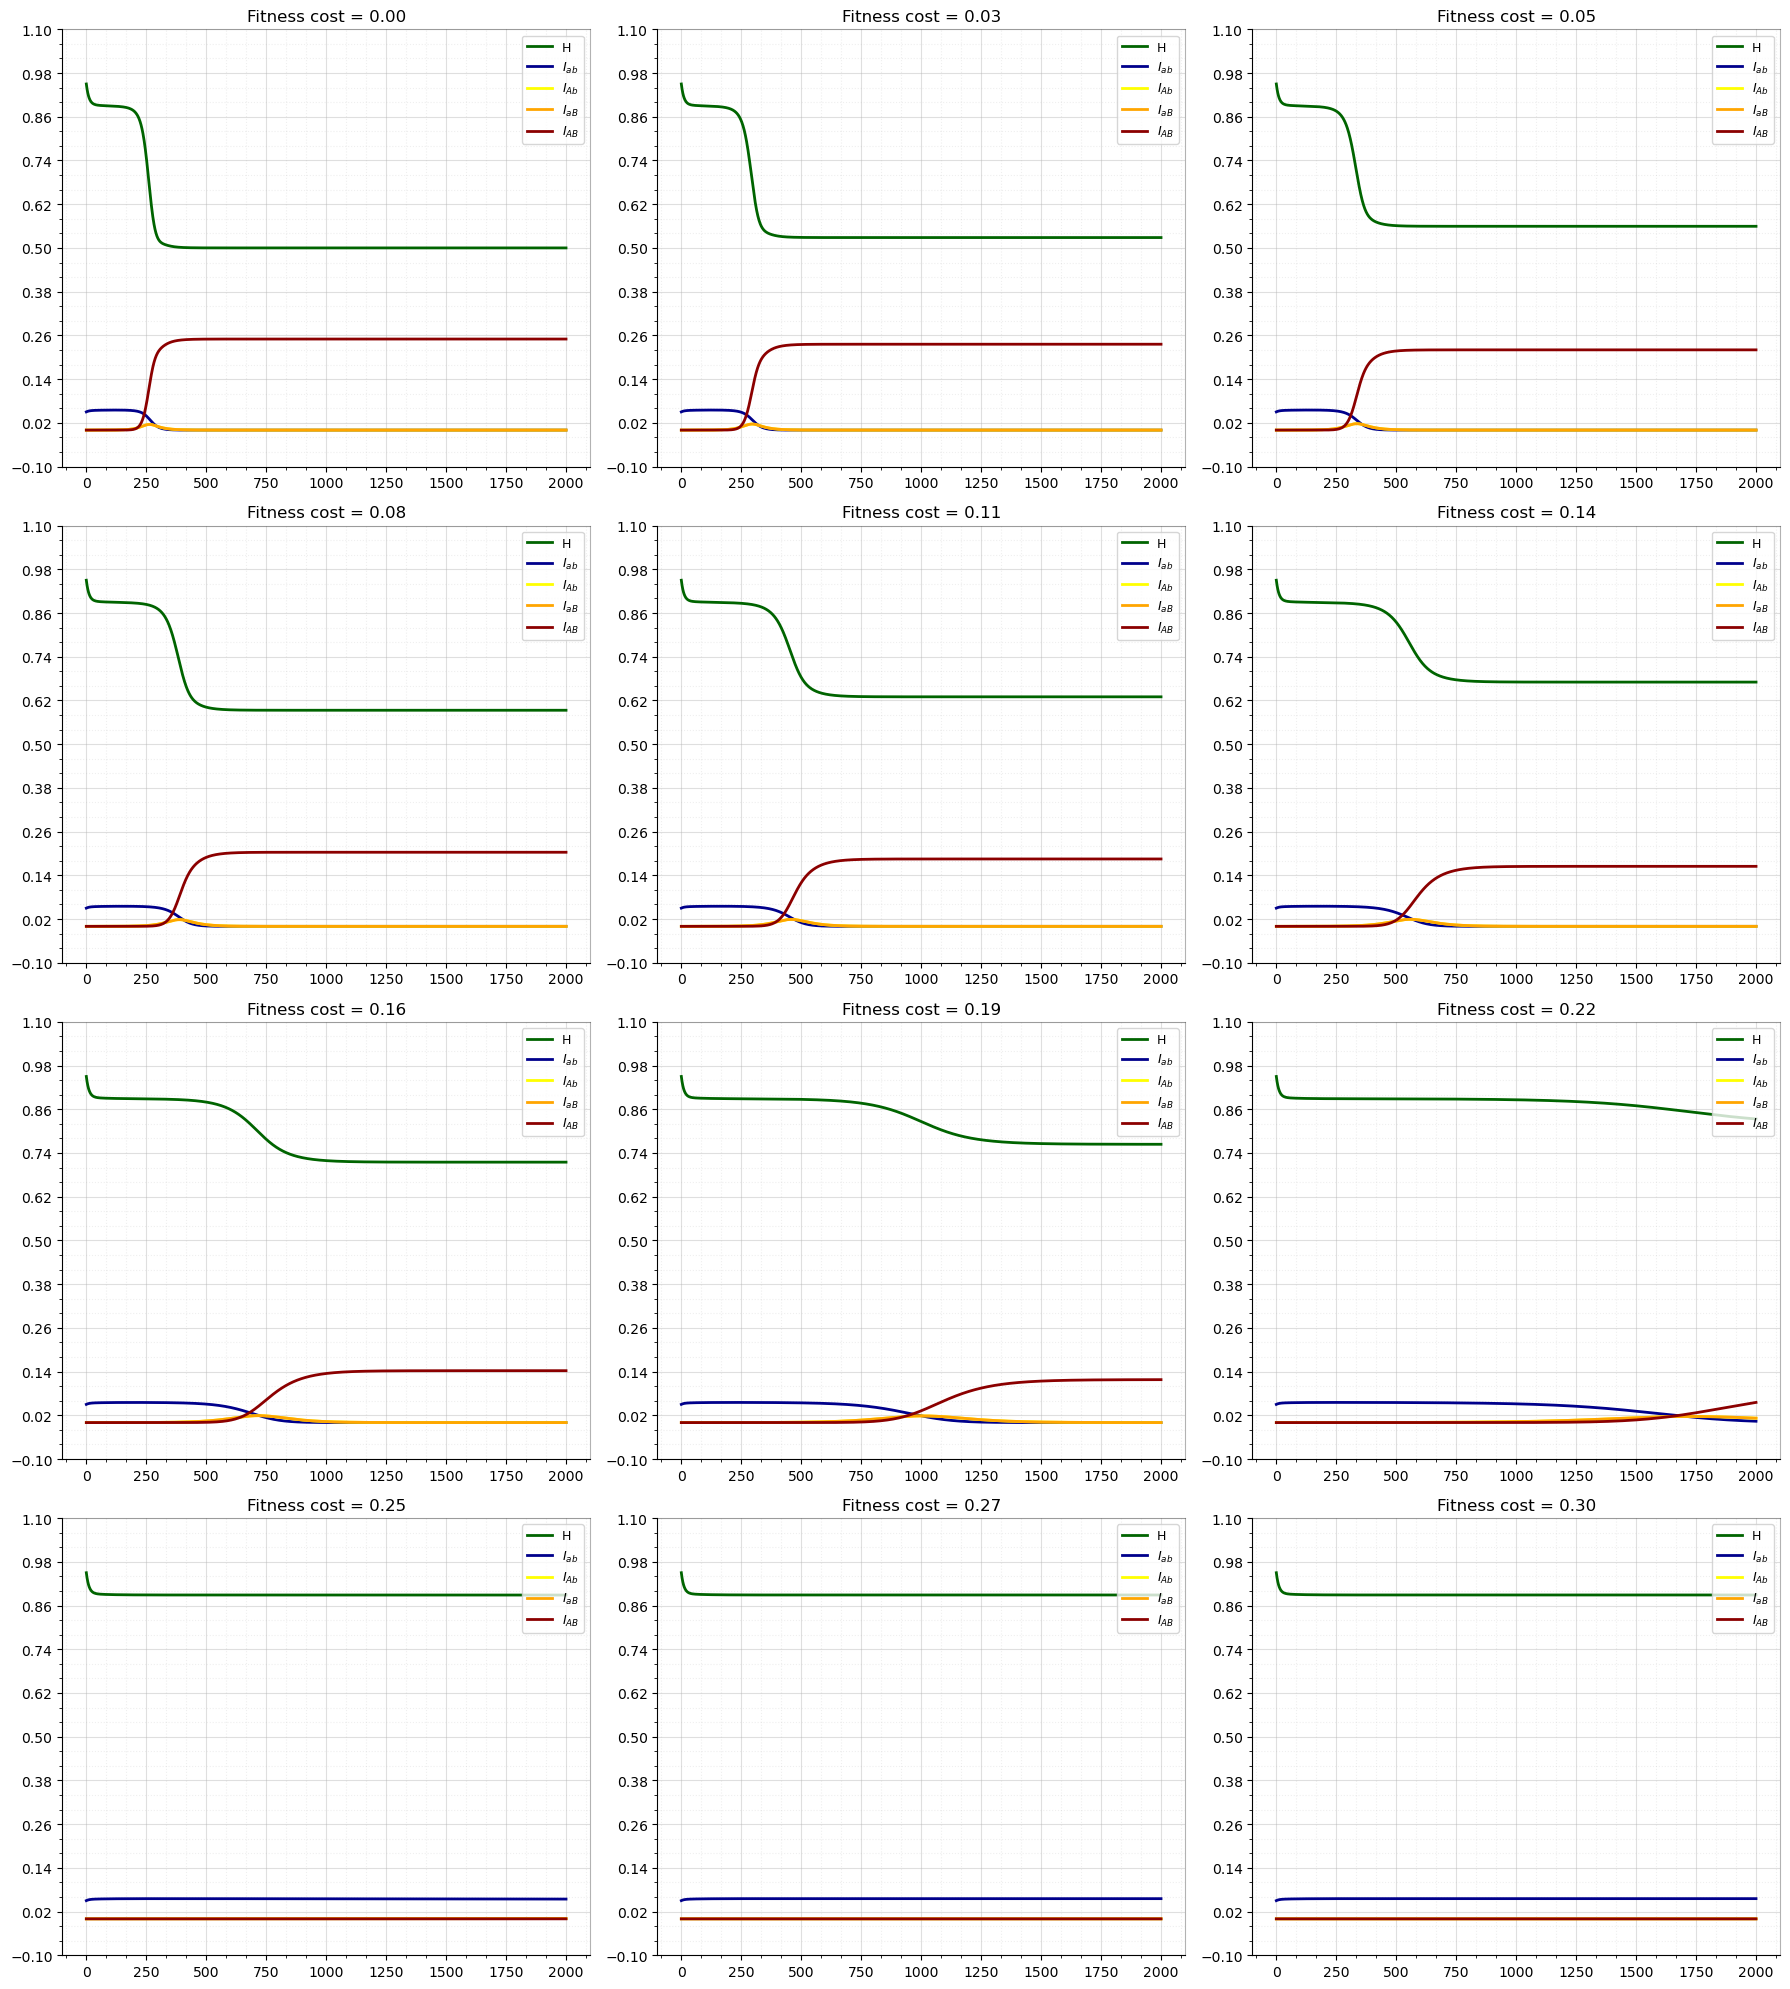

In [92]:
n = len(fitness_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, dose in enumerate (fitness_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]

    sol = full_fitness_dynamics[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], label=labels[j], linewidth=2)

    ax.set_title(f"Fitness cost = {dose:.2f}", fontsize=12)
    ax.set_ylim(-0.05, 1.1)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))

    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

#### reproductive number $R_{0}$ (strain specific) of each strain under varying baseline transmission rates 

In [100]:
def calculate_R0 (b_ab, b_Ab, b_aB, b_AB, p):
    R0_ab = b_ab * p['K'] / p['mu']
    R0_Ab = b_Ab * p['K'] / p['mu']
    R0_aB = b_aB * p['K'] / p['mu']
    R0_AB = b_AB * p['K'] / p['mu']
    
    return R0_ab, R0_Ab, R0_aB, R0_AB

transmission_range = np.linspace(0.01, 0.2, 9)
R0_results = []
t90_results = []
full_dynamics_transmission = []

for transmission in transmission_range:
    p_c = p.copy()
    p_c['beta'] = transmission
    
    C_dose1, C_dose2 = dose_distribution(p_c['C_total'], 0.5)

    e_1 = Hills_function(C_dose1, p_c['kk_1'], p_c['C50'])
    e_2 = Hills_function(C_dose2, p_c['kk_2'], p_c['C50'])

    b_ab = p_c['beta'] * (1 - e_1) * (1 - e_2)
    b_Ab = p_c['beta'] * (1 - p_c['rhor']) * (1 - e_2)
    b_aB = p_c['beta'] * (1 - e_1) * (1 - p_c['rhor'])
    b_AB = p_c['beta'] * (1 - p_c['rhor'])**2

    b_total = (b_ab, b_Ab, b_aB, b_AB)
  
    sol = odeint(ODEs, y0, t, args=(p_c, *b_total),rtol=1e-10, atol=1e-12)
    sol = np.clip(sol, 0, None)
 
    
    R0_ab, R0_Ab, R0_aB, R0_AB = calculate_R0(b_ab, b_Ab, b_aB, b_AB, p_c)
   
    R0_results.append([R0_ab, R0_Ab, R0_aB, R0_AB])
    t_90 = calculate_90_threshold(sol, t)
    t90_results.append(t_90)
    full_dynamics_transmission.append(sol)

In [101]:
rows = []

for i, sol in enumerate(full_dynamics_transmission):
    rows.append([
        transmission_range[i],
        sol[-1, 0],   
        sol[-1, 1],   
        sol[-1, 2],   
        sol[-1, 3],   
        sol[-1, 4],  
        R0_results[i][0],  
        R0_results[i][1],  
        R0_results[i][2],  
        R0_results[i][3],
        t90_results[i],
    ])

df_summary = pd.DataFrame(rows, columns=[
    "Transmission rate",
    "H",
    "$I_{ab}$",
    "$I_{Ab}$",
    "$I_{aB}$",
    "$I_{AB}$",
    "$R_{0,ab}$",
    "$R_{0,Ab}$",
    "$R_{0,aB}$",
    "$R_{0,AB}$",
    "90%$I_{AB}$time"
])


df_summary

,Transmission rate,H,$I_{ab}$,$I_{Ab}$,$I_{aB}$,$I_{AB}$,"$R_{0,ab}$","$R_{0,Ab}$","$R_{0,aB}$","$R_{0,AB}$",90%$I_{AB}$time
0,0.01000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.056250,0.071250,0.071250,0.090250,NaN
1,0.03375,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.189844,0.240469,0.240469,0.304594,NaN
2,0.05750,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.323438,0.409687,0.409687,0.518937,NaN
3,0.08125,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.457031,0.578906,0.578906,0.733281,NaN
4,0.10500,1.000000,4.069837e-16,4.433673e-16,4.433673e-16,2.693713e-14,0.590625,0.748125,0.748125,0.947625,NaN
5,0.12875,0.860663,1.419999e-09,1.058704e-05,1.058704e-05,6.964709e-02,0.724219,0.917344,0.917344,1.161969,505.252626
6,0.15250,0.726626,2.785998e-09,2.077146e-05,2.077146e-05,1.366456e-01,0.857813,1.086563,1.086563,1.376313,430.215108
7,0.17625,0.628712,3.783855e-09,2.821115e-05,2.821115e-05,1.855878e-01,0.991406,1.255781,1.255781,1.590656,391.195598
8,0.20000,0.554052,4.544721e-09,3.388391e-05,3.388391e-05,2.229062e-01,1.125000,1.425000,1.425000,1.805000,388.194097


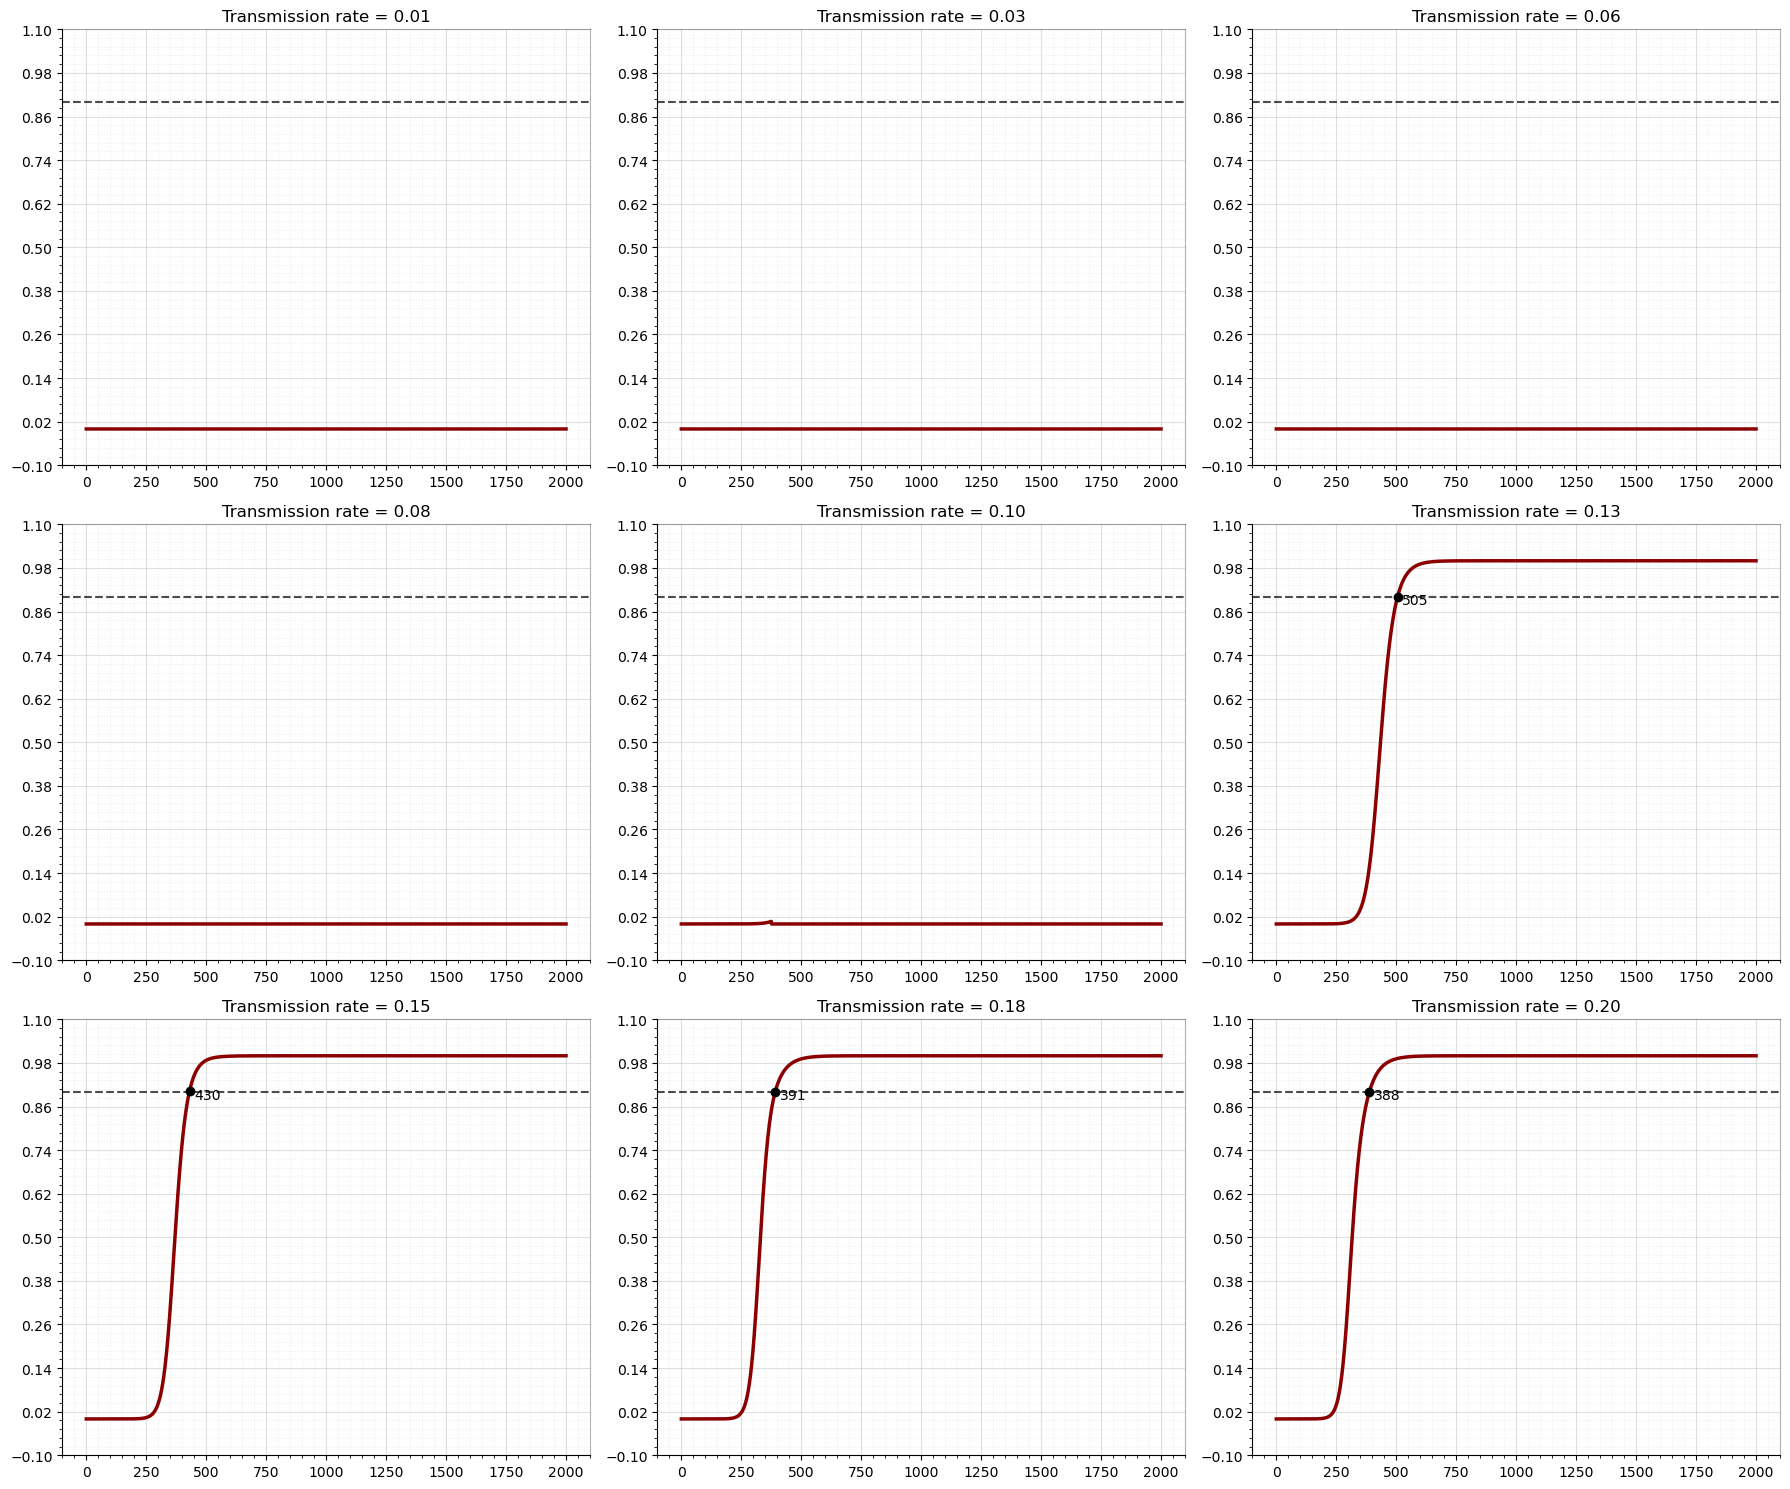

In [102]:
n = len(transmission_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

def calculate_I_AB_proportion(sol):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    I_AB = sol[:,4]
    proportion = np.divide(I_AB, I_total, out=np.zeros_like(I_total), where=(I_total > 1e-8))
    return np.clip(proportion, 0, 1)

for i, transmission in enumerate(transmission_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_dynamics_transmission[i]

    I_AB_prop = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_prop, color='darkred', linewidth=2.5)
    ax.axhline(0.9, color='black', linestyle='--', alpha=0.7)

    indices = np.where(I_AB_prop >= 0.9)[0]
    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_prop[indices[0]], 'ko')
        ax.text(hit_time + 20, 0.88, f'{hit_time:.0f}', fontsize=10)

    ax.set_title(f"Transmission rate = {transmission:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1,1.1,11))
        
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
        
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
        
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

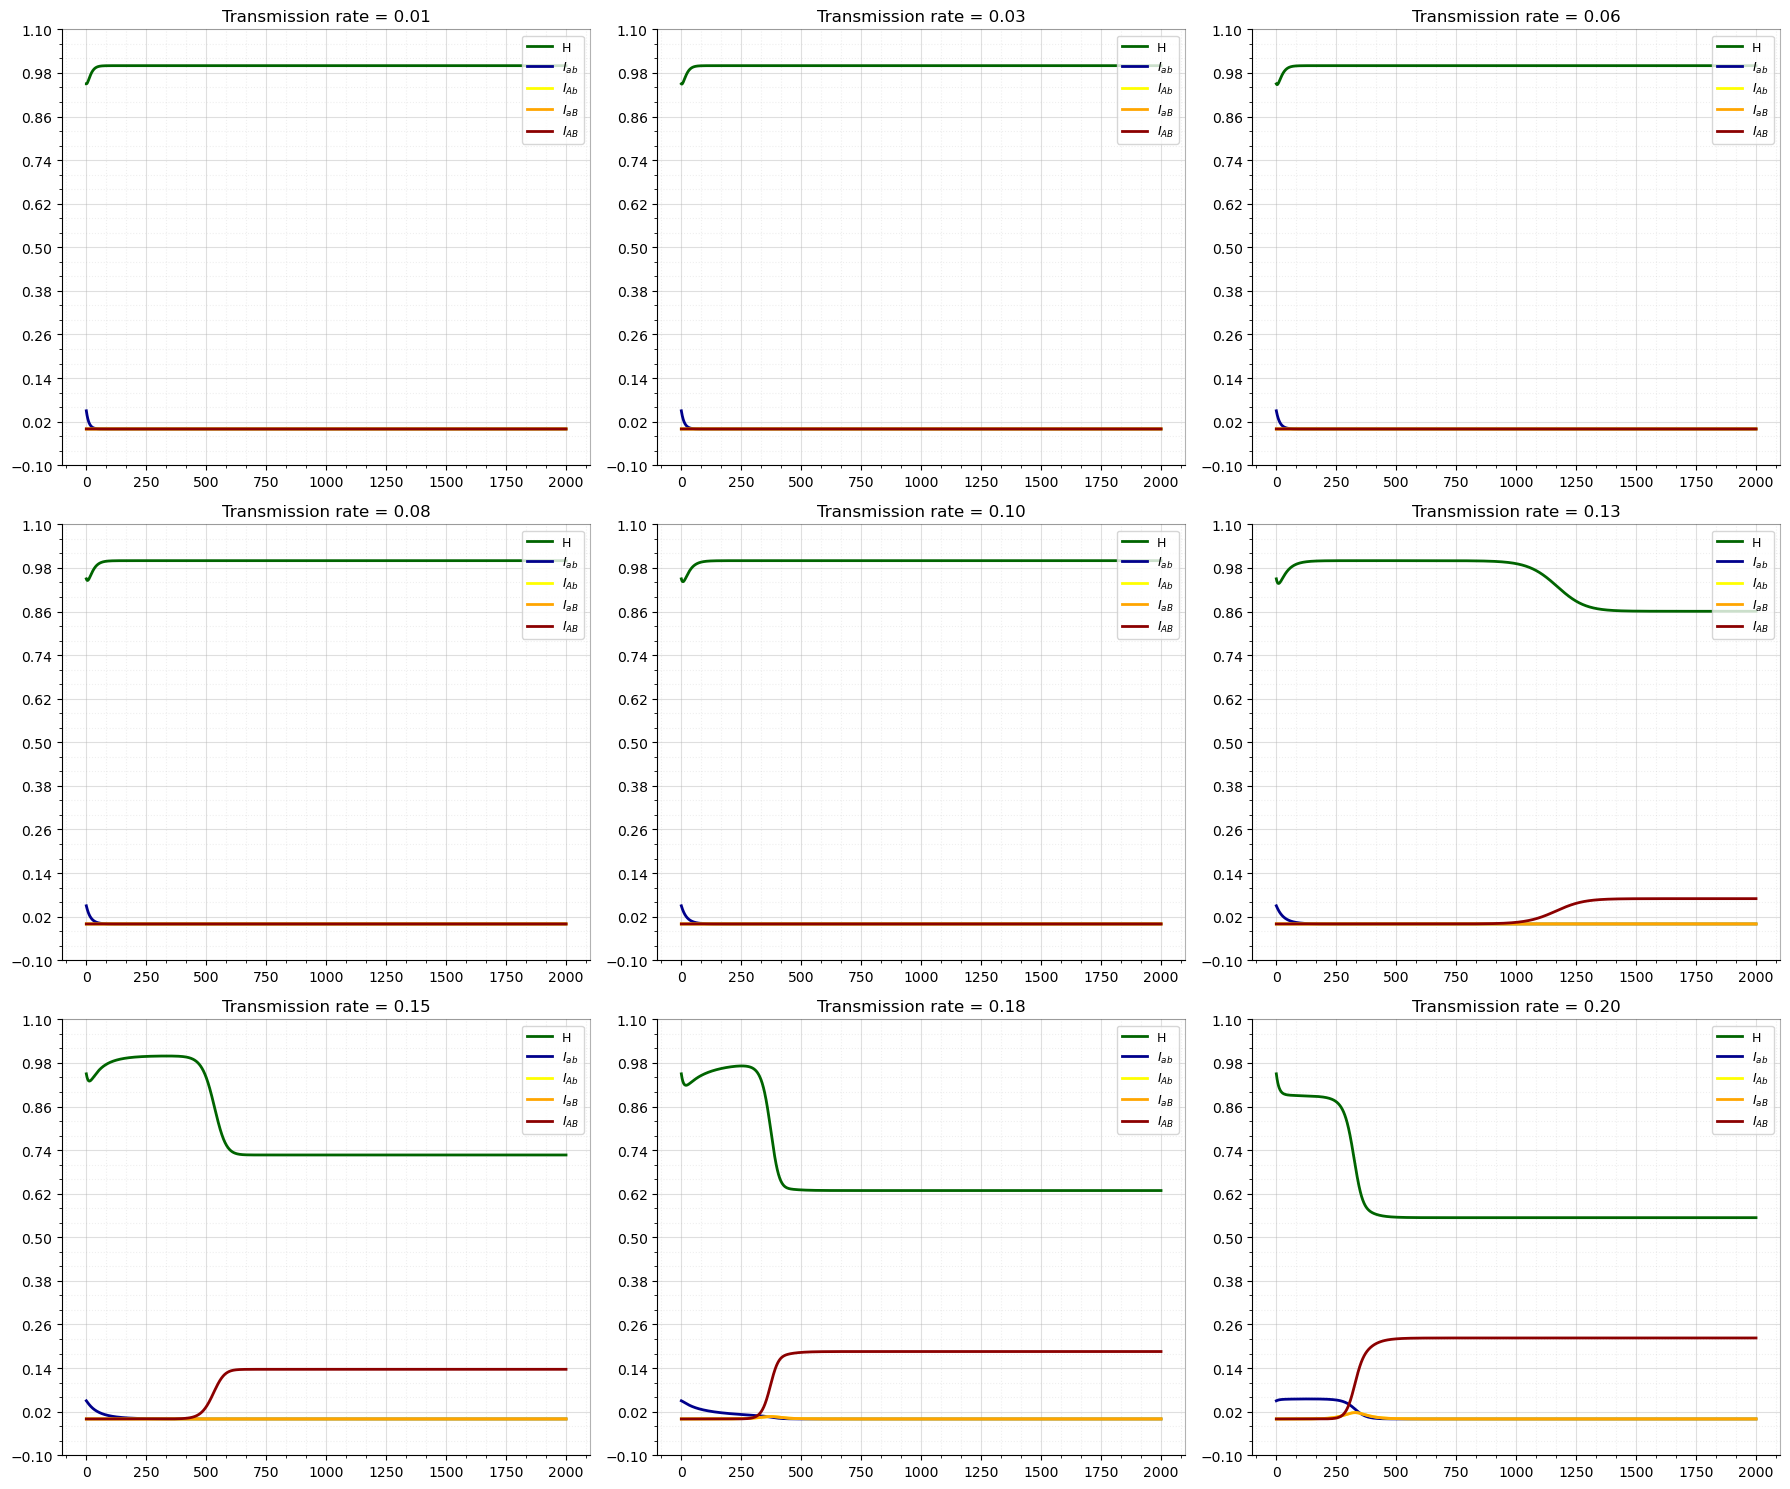

In [103]:
n = len(transmission_range)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, transmission in enumerate(transmission_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_dynamics_transmission[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], label=labels[j], linewidth=2)

    ax.set_title(f"Transmission rate = {transmission:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))
    
    ax.legend(loc='upper right', fontsize=9)
    
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
    
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

#### reproductive number $R_{0}$ (strain specific) of each strain under varying removal rates

In [104]:
def calculate_R0 (b_ab, b_Ab, b_aB, b_AB, p):
    R0_ab = b_ab * p['K'] / p['mu']
    R0_Ab = b_Ab * p['K'] / p['mu']
    R0_aB = b_aB * p['K'] / p['mu']
    R0_AB = b_AB * p['K'] / p['mu']
    
    return R0_ab, R0_Ab, R0_aB, R0_AB

removal_range = np.linspace(0.01, 0.2, 12)
R0_results = []
t90_results = []
full_removal_dynamics = []

for removal in removal_range:
    p_c = p.copy()
    p_c['mu'] = removal
    
    C_dose1, C_dose2 = dose_distribution(p_c['C_total'], 0.5)

    e_1 = Hills_function(C_dose1, p_c['kk_1'], p_c['C50'])
    e_2 = Hills_function(C_dose2, p_c['kk_2'], p_c['C50'])

    b_ab = p_c['beta'] * (1 - e_1) * (1 - e_2)
    b_Ab = p_c['beta'] * (1 - p_c['rhor']) * (1 - e_2)
    b_aB = p_c['beta'] * (1 - e_1) * (1 - p_c['rhor'])
    b_AB = p_c['beta'] * (1 - p_c['rhor'])**2

    b_total = (b_ab, b_Ab, b_aB, b_AB)
  
    sol = odeint(ODEs, y0, t, args=(p_c, *b_total),rtol=1e-10, atol=1e-12)
    sol = np.clip(sol, 0, None)
    
    R0_ab, R0_Ab, R0_aB, R0_AB = calculate_R0(b_ab, b_Ab, b_aB, b_AB, p_c)
   
    R0_results.append([R0_ab, R0_Ab, R0_aB, R0_AB])
    t_90 = calculate_90_threshold(sol, t)
    t90_results.append(t_90)
    full_removal_dynamics.append(sol)

In [77]:
rows = []

for i, sol in enumerate(full_removal_dynamics):
    rows.append([
        removal_range[i],
        sol[-1, 0],   
        sol[-1, 1],   
        sol[-1, 2],   
        sol[-1, 3],   
        sol[-1, 4],  
        R0_results[i][0],  
        R0_results[i][1],  
        R0_results[i][2],  
        R0_results[i][3],
        t90_results[i],
    ])

df_summary = pd.DataFrame(rows, columns=[
    "removal rate",
    "H",
    "$I_{ab}$",
    "$I_{Ab}$",
    "$I_{aB}$",
    "$I_{AB}$",
    "$R_{0,ab}$",
    "$R_{0,Ab}$",
    "$R_{0,aB}$",
    "$R_{0,AB}$",
    "90%$I_{AB}$time"
])


df_summary

,removal rate,H,$I_{ab}$,$I_{Ab}$,$I_{aB}$,$I_{AB}$,"$R_{0,ab}$","$R_{0,Ab}$","$R_{0,aB}$","$R_{0,AB}$",90%$I_{AB}$time
0,0.010000,0.086312,7.459428e-01,0.038031,0.038031,8.627655e-03,11.250000,14.250000,14.250000,18.050000,NaN
1,0.027273,0.151188,2.517562e-05,0.000918,0.000918,6.650639e-01,4.125000,5.225000,5.225000,6.618333,1380.690345
2,0.044545,0.246805,1.081054e-08,0.000080,0.000080,5.209189e-01,2.525510,3.198980,3.198980,4.052041,851.425713
3,0.061818,0.342505,8.281758e-09,0.000062,0.000062,4.061937e-01,1.819853,2.305147,2.305147,2.919853,617.308654
4,0.079091,0.438205,6.393778e-09,0.000048,0.000048,3.135974e-01,1.422414,1.801724,1.801724,2.282184,486.243122
5,0.096364,0.533905,4.838009e-09,0.000036,0.000036,2.372912e-01,1.167453,1.478774,1.478774,1.873113,402.201101
6,0.113636,0.629605,3.533812e-09,0.000026,0.000026,1.733239e-01,0.990000,1.254000,1.254000,1.588400,345.172586
7,0.130909,0.725305,2.424731e-09,0.000018,0.000018,1.189264e-01,0.859375,1.088542,1.088542,1.378819,328.164082
8,0.148182,0.821004,1.470027e-09,0.000011,0.000011,7.210083e-02,0.759202,0.961656,0.961656,1.218098,326.163082
9,0.165455,0.916704,6.395649e-10,0.000005,0.000005,3.136892e-02,0.679945,0.861264,0.861264,1.090934,326.163082


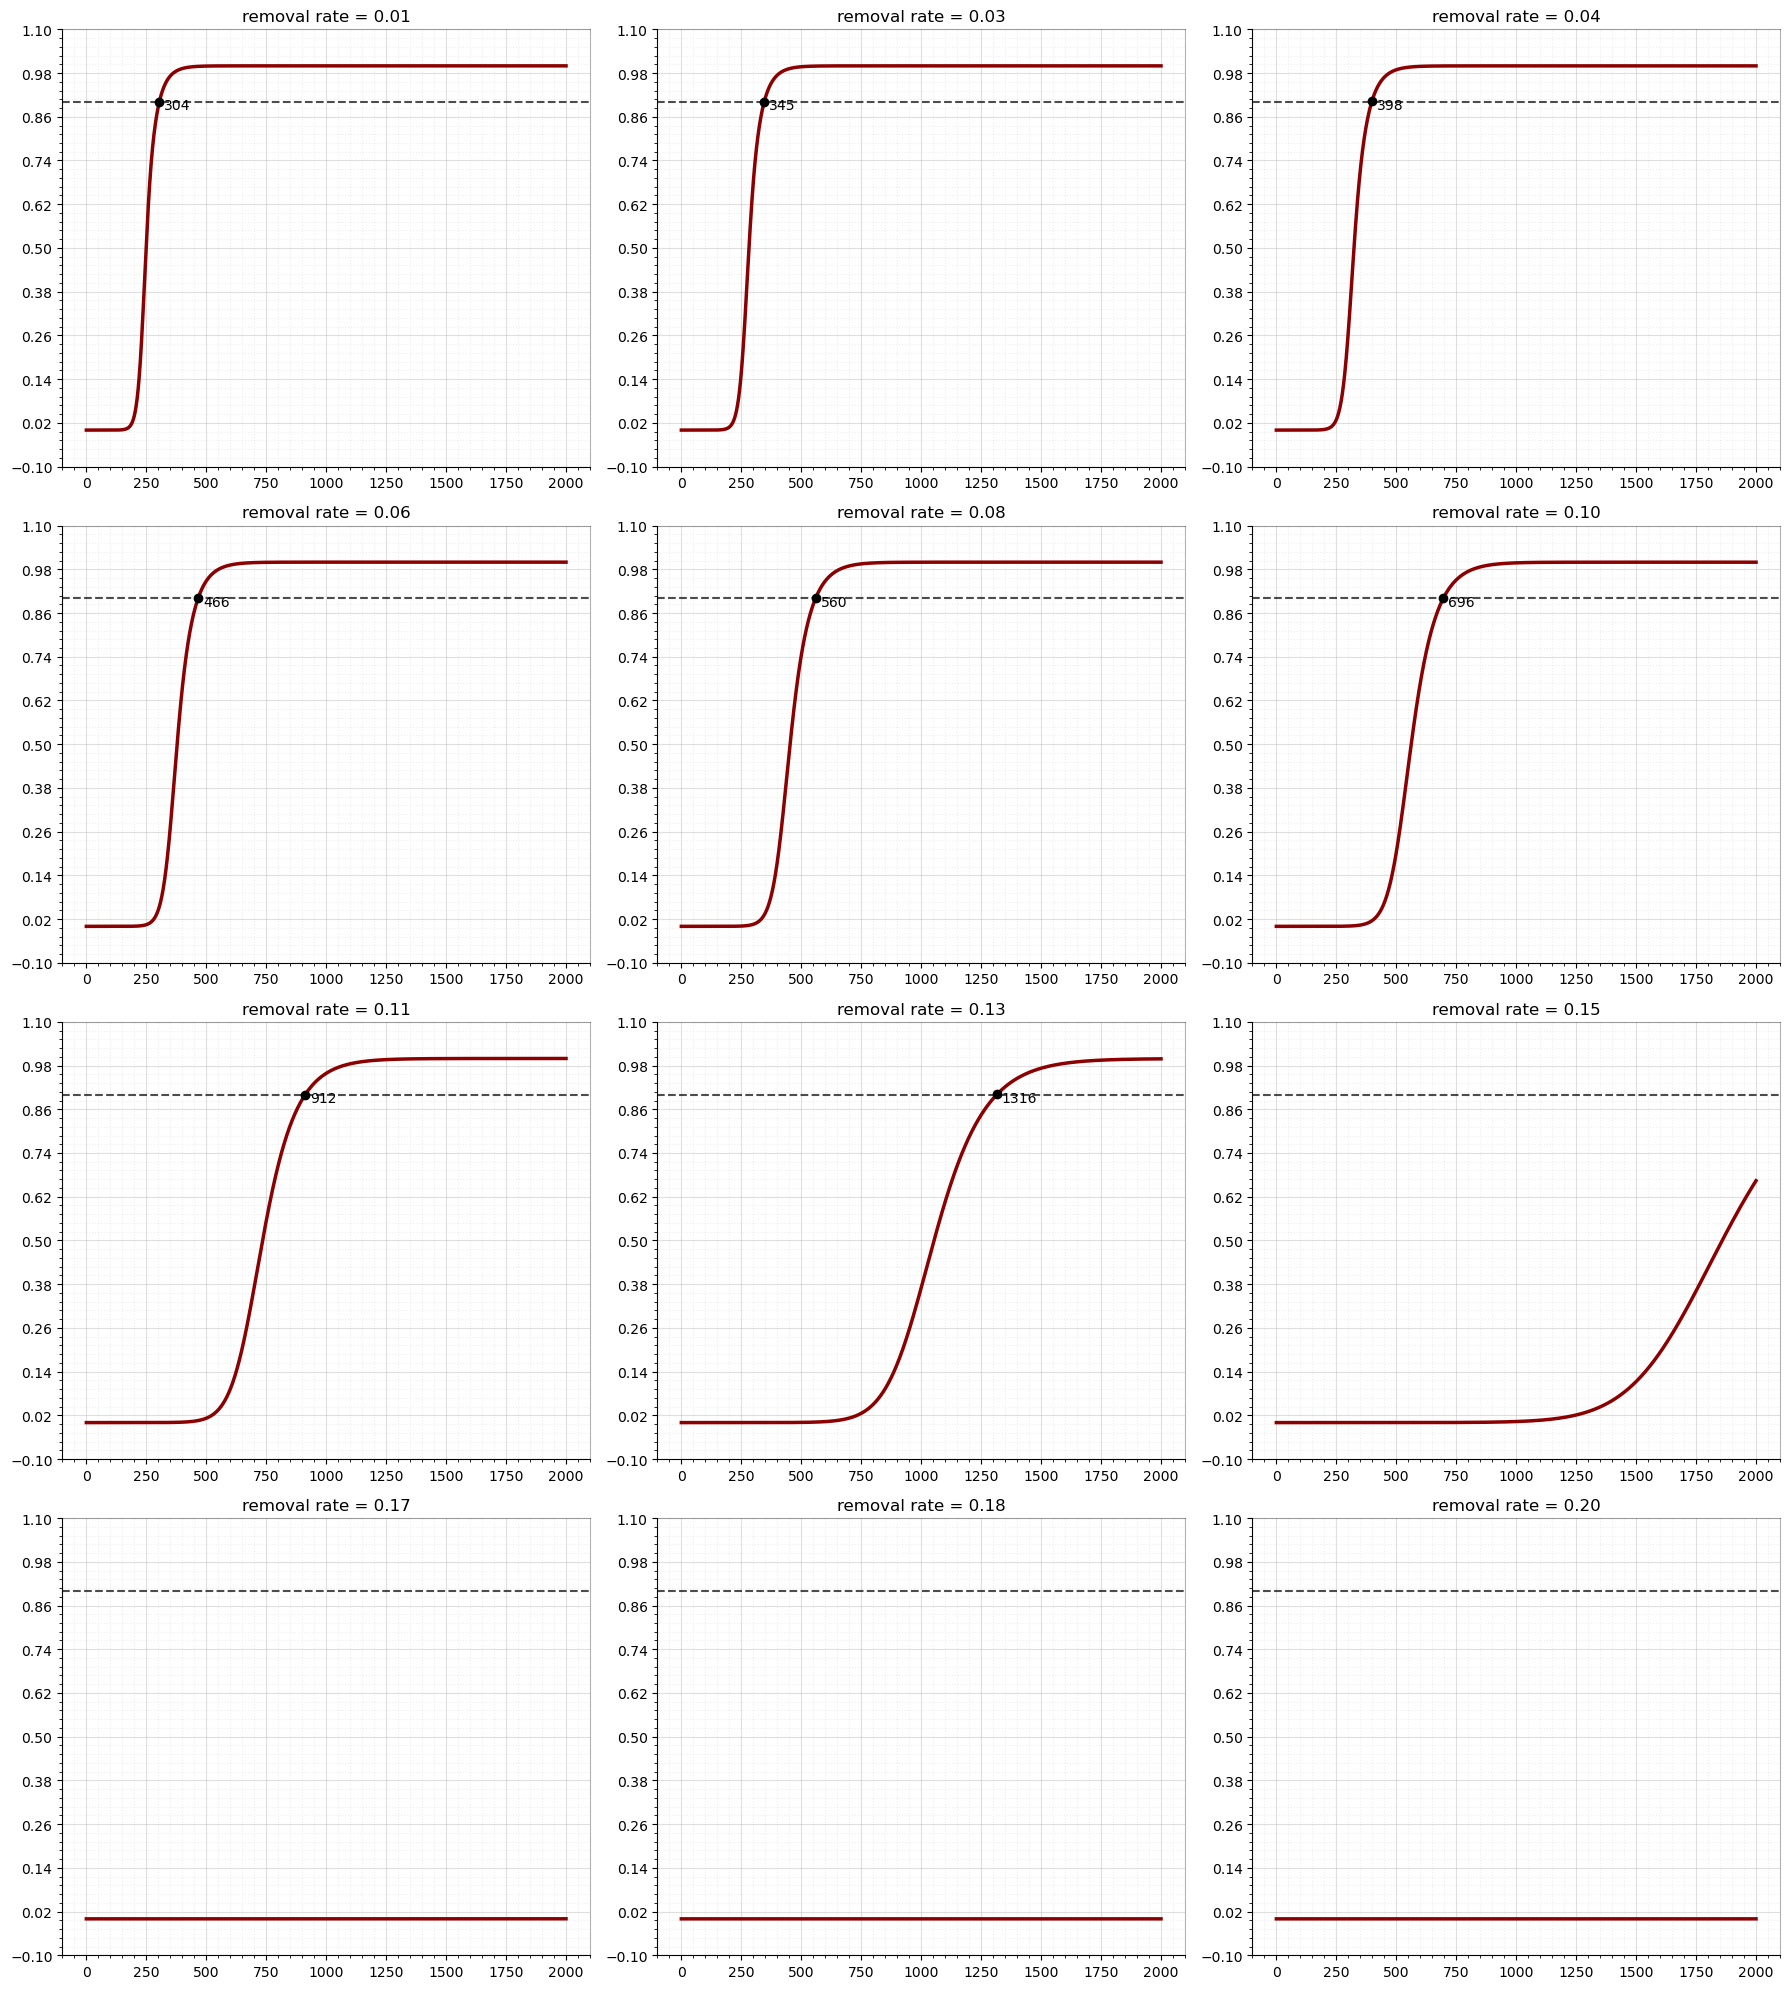

In [105]:
n = len(removal_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

def calculate_I_AB_proportion(sol):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    I_AB = sol[:,4]
    proportion = np.divide(I_AB, I_total, out=np.zeros_like(I_total), where=(I_total > 1e-8))
    return np.clip(proportion, 0, 1)

for i, removal in enumerate(removal_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_dynamics[i]

    I_AB_prop = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_prop, color='darkred', linewidth=2.5)
    ax.axhline(0.9, color='black', linestyle='--', alpha=0.7)

    indices = np.where(I_AB_prop >= 0.9)[0]
    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_prop[indices[0]], 'ko')
        ax.text(hit_time + 20, 0.88, f'{hit_time:.0f}', fontsize=10)

    ax.set_title(f"removal rate = {removal:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1,1.1,11))
        
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
        
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
        
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

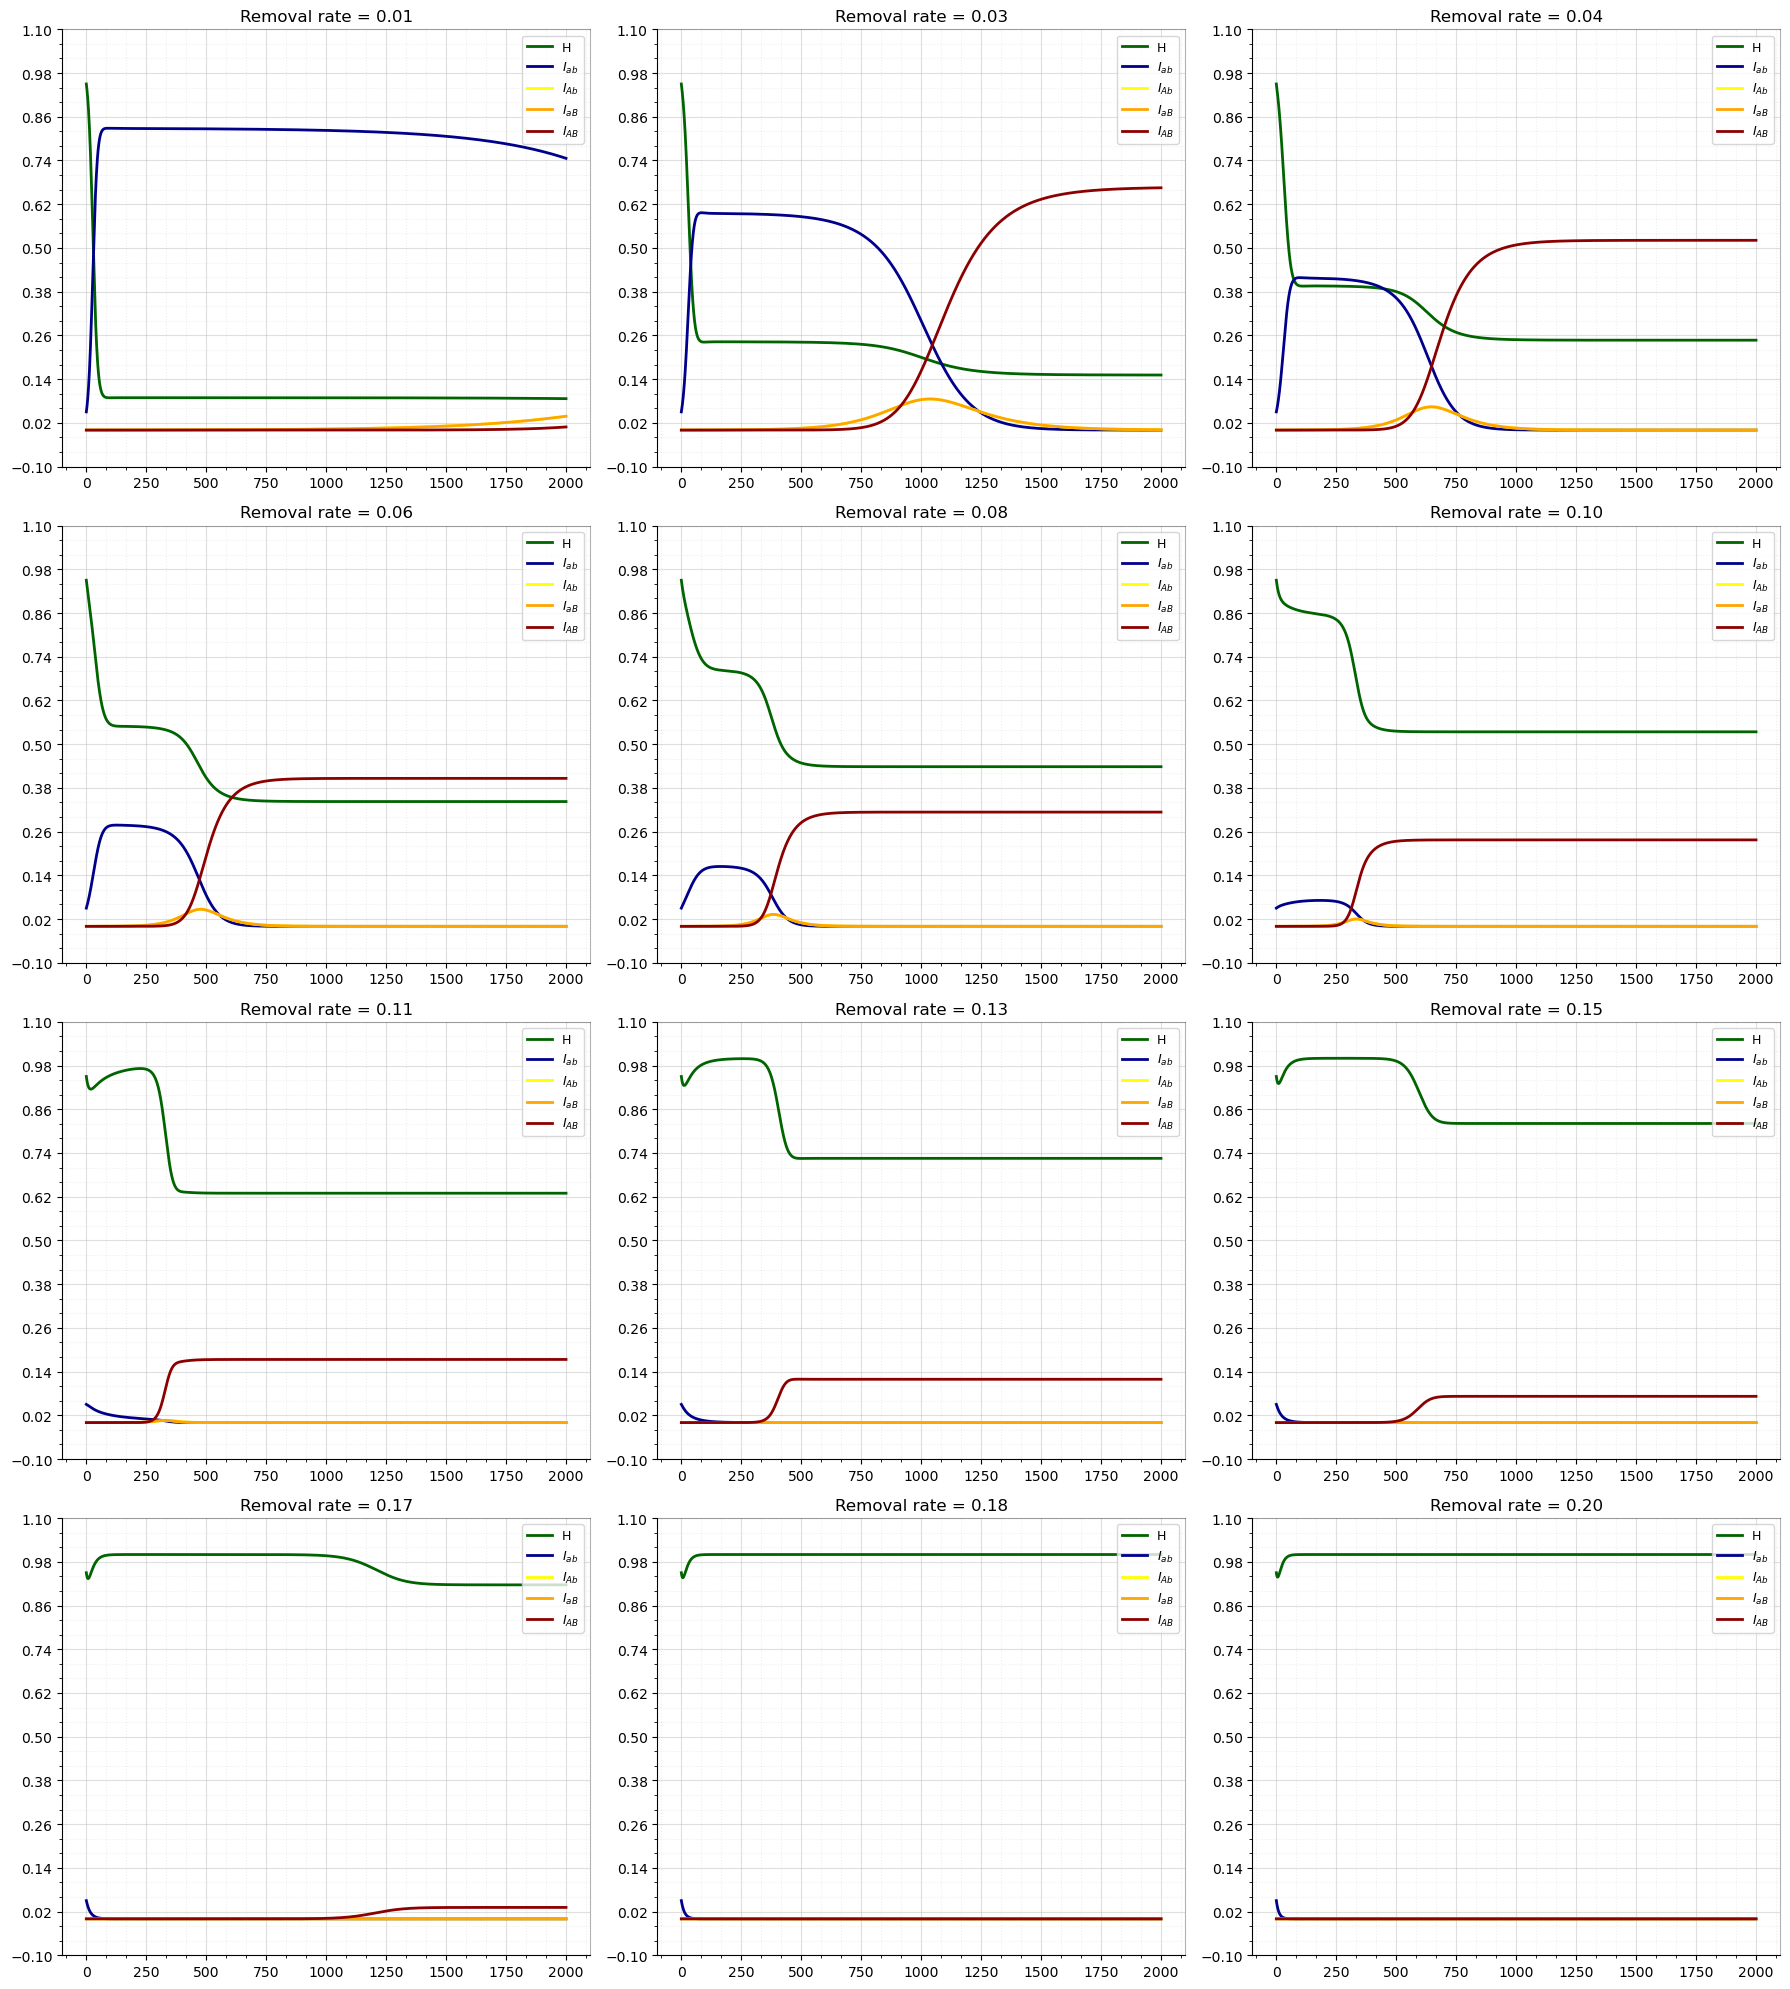

In [80]:
n = len(removal_range)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, removal in enumerate(removal_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_removal_dynamics[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], label=labels[j], linewidth=2)

    ax.set_title(f"Removal rate = {removal:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))
    
    ax.legend(loc='upper right', fontsize=9)
    
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
    
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()